<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical Inversion & Seismic Tomography — A Companion Notebook

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 12 — Practical Inversion Methods & Seismic Tomography**

This notebook builds the full seismic tomography pipeline from scratch:

1. **The slant-stack method** — converting a T(X) curve to the \u03c4(p) domain by building the envelope of a family of lines.
2. **A block tomography model** — tracing straight rays through a grid and building the sparse G matrix derived in lecture.
3. **Damped least squares and the L-curve** — regularizing the ill-posed inverse problem and choosing \u03bb automatically.
4. **Laplacian (smoothness) regularization** — comparing zeroth-order and roughness-penalized solutions on a synthetic checkerboard-like model.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pylab as plt

plt.rcParams["figure.figsize"] = (8, 6)

## Part 1 — The Slant-Stack Method

Each point $(X_i, T_i)$ on a travel-time curve corresponds to a straight line $\tau = T_i - p X_i$ in the $(p,\tau)$ domain. The $\tau(p)$ curve is the lower envelope of the whole family of such lines.

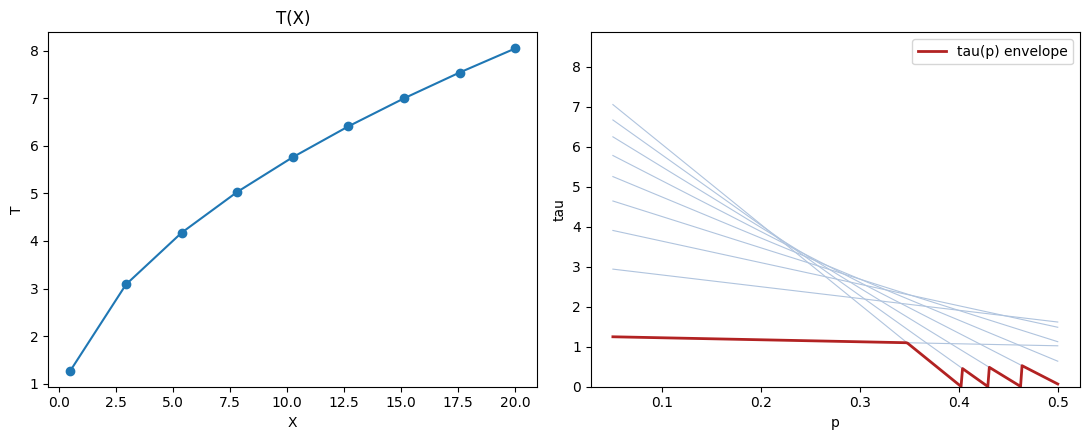

In [2]:
# A synthetic concave travel-time curve
X_data = np.linspace(0.5, 20, 9)
T_data = 2.0 * np.sqrt(X_data) * 0.9

p_grid = np.linspace(0.05, 0.5, 300)
tau_envelope = np.full_like(p_grid, np.inf)
for X, T in zip(X_data, T_data):
    tau_line = T - p_grid * X
    tau_envelope = np.minimum(tau_envelope, np.where(tau_line > 0, tau_line, np.inf))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(X_data, T_data, "o-")
axes[0].set_xlabel("X"); axes[0].set_ylabel("T"); axes[0].set_title("T(X)")
for X, T in zip(X_data, T_data):
    axes[1].plot(p_grid, T - p_grid * X, color="lightsteelblue", linewidth=0.8)
axes[1].plot(p_grid, tau_envelope, color="firebrick", linewidth=2, label="tau(p) envelope")
axes[1].set_ylim(0, T_data.max() * 1.1)
axes[1].set_xlabel("p"); axes[1].set_ylabel("tau"); axes[1].legend()
plt.tight_layout()
plt.show()

## Part 2 — Building a Block Tomography G Matrix

Now the heart of tomography: tracing a straight ray through a grid of blocks and recording how much path length it spends in each cell. Stacking many rays builds the sparse G matrix from lecture.

In [3]:
def ray_block_lengths(src, rcv, n_blocks):
    """Path length of a straight ray through each cell of an n_blocks x n_blocks grid."""
    lengths = np.zeros((n_blocks, n_blocks))
    n_steps = 3000
    pts = np.linspace(src, rcv, n_steps)
    ds = np.linalg.norm(np.array(rcv) - np.array(src)) / n_steps
    for x, y in pts:
        i, j = int(y), int(x)
        if 0 <= i < n_blocks and 0 <= j < n_blocks:
            lengths[i, j] += ds
    return lengths.flatten()

In [4]:
n_blocks = 8
np.random.seed(3)
n_rays = 40
sources = np.column_stack([np.zeros(n_rays), np.random.uniform(0, n_blocks, n_rays)])
receivers = np.column_stack([np.full(n_rays, n_blocks), np.random.uniform(0, n_blocks, n_rays)])

G = np.array([ray_block_lengths(s, r, n_blocks) for s, r in zip(sources, receivers)])
print(f"G shape: {G.shape}  (n_rays x n_blocks^2)")
print(f"Sparsity: {100*np.mean(G == 0):.1f}% of entries are exactly zero")

G shape: (40, 64)  (n_rays x n_blocks^2)
Sparsity: 84.5% of entries are exactly zero


### A synthetic "true" model and forward-computed data

Let's put a single fast anomaly in the middle of the grid, forward-compute travel-time residuals through it, then see if we can recover the anomaly by inverting.

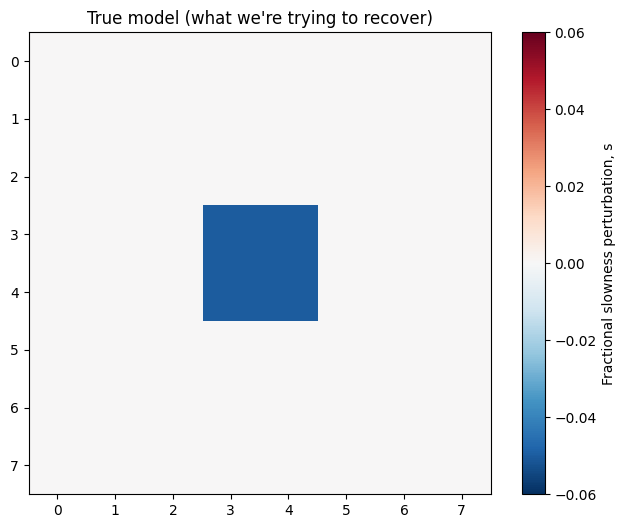

In [5]:
true_model = np.zeros((n_blocks, n_blocks))
true_model[3:5, 3:5] = -0.05   # a 5%-fast anomaly in the center
d_obs = G @ true_model.flatten()
d_obs += np.random.normal(0, 0.001, size=d_obs.shape)  # small picking noise

plt.imshow(true_model, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
plt.colorbar(label="Fractional slowness perturbation, s")
plt.title("True model (what we're trying to recover)")
plt.show()

## Part 3 — Damped Least Squares & the L-Curve

The system is underdetermined and ill-conditioned (many blocks have few or no rays through them), so we regularize with a damping term and sweep $\lambda$ to find a good tradeoff.

In [6]:
lambdas = np.logspace(-4, 0, 30)
resid_norms, model_norms, models = [], [], []
for lam in lambdas:
    A = np.vstack([G, lam * np.eye(G.shape[1])])
    b = np.concatenate([d_obs, np.zeros(G.shape[1])])
    m_lam, *_ = np.linalg.lstsq(A, b, rcond=None)
    resid_norms.append(np.linalg.norm(G @ m_lam - d_obs))
    model_norms.append(np.linalg.norm(m_lam))
    models.append(m_lam)

resid_norms, model_norms = np.array(resid_norms), np.array(model_norms)

# Find the L-curve corner: point of max distance from the line joining the endpoints
log_r, log_m = np.log10(resid_norms), np.log10(model_norms)
p1, p2 = np.array([log_r[0], log_m[0]]), np.array([log_r[-1], log_m[-1]])
line_vec = (p2 - p1) / np.linalg.norm(p2 - p1)
pts = np.column_stack([log_r, log_m]) - p1
perp_dist = np.linalg.norm(pts - np.outer(pts @ line_vec, line_vec), axis=1)
corner_idx = np.argmax(perp_dist)
print(f"Chosen lambda = {lambdas[corner_idx]:.4f}")

Chosen lambda = 0.1487


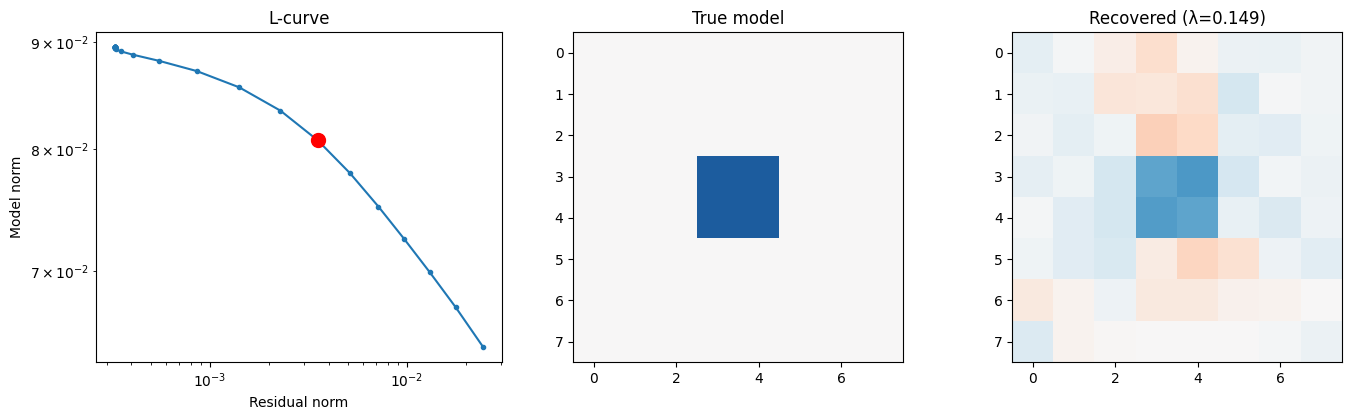

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
axes[0].loglog(resid_norms, model_norms, "o-", markersize=3)
axes[0].plot(resid_norms[corner_idx], model_norms[corner_idx], "o", color="red", markersize=10)
axes[0].set_xlabel("Residual norm"); axes[0].set_ylabel("Model norm"); axes[0].set_title("L-curve")

axes[1].imshow(true_model, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[1].set_title("True model")

recovered = models[corner_idx].reshape(n_blocks, n_blocks)
axes[2].imshow(recovered, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[2].set_title(f"Recovered (\u03bb={lambdas[corner_idx]:.3f})")
plt.tight_layout()
plt.show()

The recovered image is smeared (as expected — the model is under-determined and this is zeroth-order damping, which penalizes model *size*, not roughness), but the anomaly's location and negative (fast) sign come through clearly.

## Part 4 — Laplacian (Smoothness) Regularization

Now let's build the Laplacian operator matrix L and compare a roughness-penalized solution to the damped-least-squares result above.

In [8]:
def build_laplacian(n_blocks):
    """L such that (L @ m)[j] approximates the discrete Laplacian at block j
    (zero at the grid edges, for simplicity)."""
    n = n_blocks * n_blocks
    L = np.zeros((n, n))
    for i in range(n_blocks):
        for j in range(n_blocks):
            idx = i * n_blocks + j
            neighbors = []
            if i > 0: neighbors.append((i - 1, j))
            if i < n_blocks - 1: neighbors.append((i + 1, j))
            if j > 0: neighbors.append((i, j - 1))
            if j < n_blocks - 1: neighbors.append((i, j + 1))
            L[idx, idx] = -1.0
            for (ni, nj) in neighbors:
                L[idx, ni * n_blocks + nj] = 1.0 / len(neighbors)
    return L

L = build_laplacian(n_blocks)
lam_L = 0.05
A_L = np.vstack([G, lam_L * L])
b_L = np.concatenate([d_obs, np.zeros(G.shape[1])])
m_smooth, *_ = np.linalg.lstsq(A_L, b_L, rcond=None)
recovered_smooth = m_smooth.reshape(n_blocks, n_blocks)

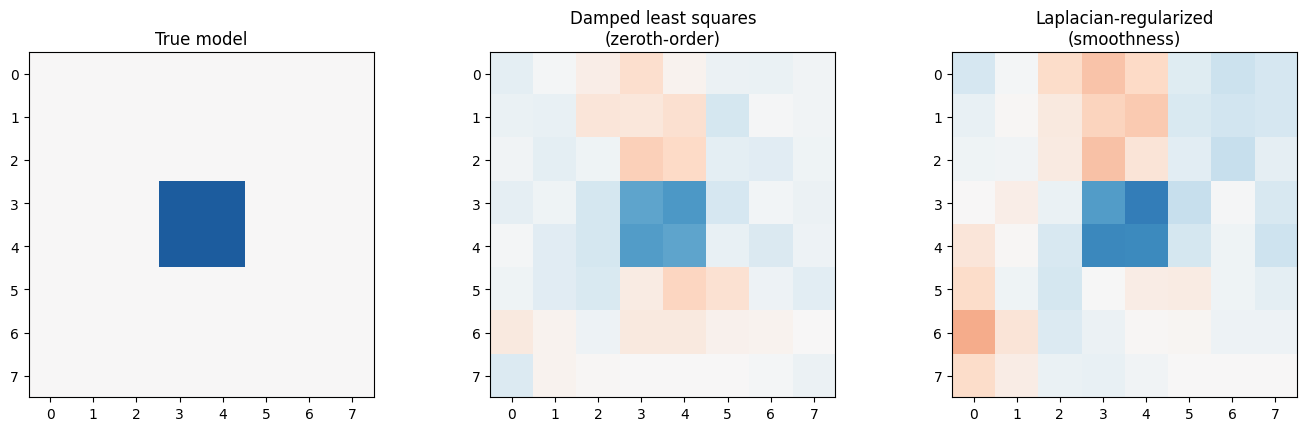

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
axes[0].imshow(true_model, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[0].set_title("True model")
axes[1].imshow(recovered, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[1].set_title("Damped least squares\n(zeroth-order)")
axes[2].imshow(recovered_smooth, cmap="RdBu_r", vmin=-0.06, vmax=0.06)
axes[2].set_title("Laplacian-regularized\n(smoothness)")
plt.tight_layout()
plt.show()

Both regularizations recover the anomaly's location and sign, but with different artifacts — exactly the tradeoff lecture describes: zeroth-order damping minimizes model *size*, so unconstrained blocks tend toward zero; Laplacian regularization minimizes *roughness*, so unconstrained blocks tend to match their neighbors instead, spreading the anomaly out more smoothly.

## Summary & Further Resources

- **Slant-stack** — the $\tau(p)$ curve is the lower envelope of a family of straight lines, one per $(X,T)$ data point.
- **The tomography G matrix** — built directly by tracing rays through a block grid and recording path length per cell; genuinely sparse for realistic ray/block geometries.
- **The L-curve** — automatically balances data fit against model size, found here as the point of maximum distance from the line joining the sweep's endpoints.
- **Laplacian regularization** — trades zeroth-order damping's "shrink toward zero" bias for a "match your neighbors" bias, usually giving smoother, more physically plausible tomographic images.

**For further reading:**
- Aster, R. C., B. Borchers, and C. H. Thurber, *Parameter Estimation and Inverse Problems* — the standard reference for damped least squares, Tikhonov regularization, and L-curve analysis.
- Nolet, G., *A Breviary of Seismic Tomography* — a thorough treatment of block and spherical-harmonic parameterizations, ray tracing through 3-D models, and resolution analysis (previewed further in Lecture 13).